In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src import data_processing as dp
from src import cost_calculations as cc
from src import pulp_optimiser as po
%load_ext autoreload
%autoreload 2

In [2]:
CONFIG = dp.ElectricityConfig.from_yaml("../config/config.yaml")
df_hourly = dp.process_heat_energy_profile(data_path='../data/heat_data.csv')
day_ahead_hourly = dp.process_day_ahead_data(df_hourly, data_path='../data/day_ahead_1yr.csv')

df_usage_and_price = dp.calculate_usage_and_price(df_hourly, day_ahead_hourly, config=CONFIG)

df_usage_and_price = df_usage_and_price[df_usage_and_price.datetime < '2025-12-01']


/Users/neil.sinclair@diconium.com/Projects/electricy-model/src/data_processing.py:138: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  day_ahead = pd.read_csv(data_path, sep=";")


In [3]:
optimised_results = po.solve_battery_dispatch_pulp(
    price=df_usage_and_price['c_variable_and_fixed_per_kwh'], 
    demand=df_usage_and_price['raw_kwh_usage'],
    config=CONFIG
    )

Solver status: Optimal


In [4]:
raw_cost = (df_usage_and_price['raw_kwh_usage'] * df_usage_and_price['c_variable_and_fixed_per_kwh']).sum() / 100 * (1 + CONFIG.TAX_RATE)
optimised_cost = optimised_results.total_cost / 100 * (1 + CONFIG.TAX_RATE)
print(f"Raw_cost: €{raw_cost:.2f}")
print(f"Optimised cost: €{optimised_cost:.2f}")

Raw_cost: €31388.80
Optimised cost: €28947.77


In [6]:
df_usage_and_price['c_variable_total_cost_with_battery'] = optimised_results.grid * df_usage_and_price['c_variable_and_fixed_per_kwh'] * (1 + CONFIG.TAX_RATE)

In [7]:

np.sum(optimised_results.grid), df_usage_and_price['raw_kwh_usage'].sum()

(np.float64(109640.032082202), np.float64(106311.338592423))

In [8]:
profile_with_battery = (
    pd.DataFrame({
        'datetime': df_usage_and_price['datetime'],
        'raw_kwh_usage': df_usage_and_price['raw_kwh_usage'],
        'grid_kwh_usage': optimised_results.grid,
        'soc': optimised_results.soc,
        'battery_charge_kwh': optimised_results.charge,
        'battery_discharge_kwh': optimised_results.discharge,
    }
))

profile_with_battery['battery_charge_net'] = profile_with_battery['battery_charge_kwh'] - profile_with_battery['battery_discharge_kwh']

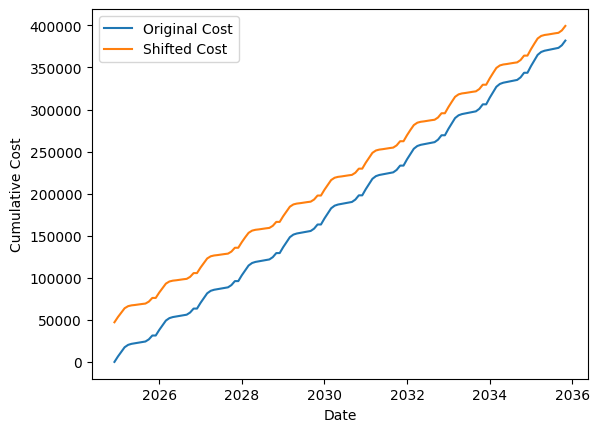

In [ ]:
import matplotlib.pyplot as plt
projections = cc.calculate_projections(df_usage_and_price, config=CONFIG)
battery_capex = (CONFIG.BATTERY_SIZE_KWH * CONFIG.BATTERY_COST_PER_KWH * (1 + CONFIG.TAX_RATE))

projections.loc[:, "c_variable_total_cost_with_battery_cumulative"] = (
    projections.loc[:, "c_variable_total_cost_with_battery_cumulative"]/100 
    + battery_capex + (battery_capex * CONFIG.OPEX_PERCENT_OF_CAPEX)
)

projections["c_total_variable_cost_cumulative"] = projections["c_total_variable_cost_cumulative"] / 100

plt.plot(projections["datetime"], projections["c_total_variable_cost_cumulative"], label="Original Cost")
plt.plot(projections["datetime"], projections["c_variable_total_cost_with_battery_cumulative"], label="Shifted Cost")
plt.xlabel("Date")
plt.ylabel("Cumulative Cost")
plt.legend()
plt.show()